<a href="https://colab.research.google.com/github/Maartzzz/Modelado-Platano/blob/main/ModPredBrix2Isla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Prediccion de calidad del plátano peruano por medio del Brix, quimiometría combinada con espectroscopía NIR y modelos de IA*

---



# Preparación de datos

In [1]:
# ============================================================
# INSTALACIÓN DE LIBRERÍAS
# ============================================================

!pip -q install openpyxl
!pip -q install xgboost
!pip -q install tqdm

In [14]:
# ============================================================
# LIBRERÍAS
# ============================================================

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

np.random.seed(42)

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

import os

RANDOM_STATE = 42

# Archivo ZIP con los espectros
ZIP_FILE = "/content/platano - isla.zip"

# Excel con los valores de °Brix
PATH_BRIX = "/content/PS-datosBrixIsla.xlsx"

# Carpeta donde se extraerán los espectros
EXTRACT_FOLDER = "/content/platano-isla"

# Carpeta de resultados
RESULTS_DIR = "/content/Resultados"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [15]:
# ============================================================
# DESCOMPRESIÓN AUTOMÁTICA DEL ZIP
# ============================================================

import zipfile
import shutil

# Elimina la carpeta anterior si existe
if os.path.exists(EXTRACT_FOLDER):
    shutil.rmtree(EXTRACT_FOLDER)

# Descomprime el ZIP
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_FOLDER)

print("Archivos extraídos correctamente.")

# ============================================================
# BÚSQUEDA AUTOMÁTICA DE ARCHIVOS
# ============================================================

def list_spectra_files(folder):

    files = glob.glob(
        os.path.join(folder, "**", "*.xlsx"),
        recursive = True
        )

    print(f"Archivos encontrados: {len(files)}")

    return sorted(files)

# ============================================================
# LECTURA DE UN ESPECTRO
# ============================================================

def read_spectrum(file):

    df = pd.read_excel(file)

    wavelength = df.iloc[:,0].values

    spectrum = df.iloc[:,1].values

    return wavelength, spectrum

files = list_spectra_files(EXTRACT_FOLDER)

Archivos extraídos correctamente.
Archivos encontrados: 180


In [16]:
spectra = []
sample_names = []

for file in tqdm(files):

    wl, sp = read_spectrum(file)

    spectra.append(sp)

    sample_names.append(os.path.basename(file))

# Verificar dimensiones
lengths = [len(s) for s in spectra]

print("Longitudes encontradas:")
print(pd.Series(lengths).value_counts().sort_index())

100%|██████████| 180/180 [00:55<00:00,  3.22it/s]

Longitudes encontradas:
208    180
Name: count, dtype: int64


In [17]:
# ============================================================
# LECTOR ROBUSTO DE ESPECTROS NIR
# Compatible con:
#   - Archivos exportados en cm⁻¹
#   - Archivos exportados en nm
#   - Diferentes resoluciones espectrales
# ============================================================

from scipy.interpolate import interp1d

def read_nir_file(filepath, master_axis=None):

    # --------------------------------------------------------
    # Leer archivo sin interpretar encabezados
    # --------------------------------------------------------
    df = pd.read_excel(filepath, header=None)

    # Eliminar las primeras 5 filas de metadatos
    df = df.iloc[5:].reset_index(drop=True)

    # --------------------------------------------------------
    # Primera columna -> eje espectral
    # --------------------------------------------------------
    axis = pd.to_numeric(df.iloc[:,0], errors="coerce").values

    # --------------------------------------------------------
    # Columnas restantes -> escaneos
    # --------------------------------------------------------
    spectra = df.iloc[:,1:]

    spectra = spectra.apply(pd.to_numeric, errors="coerce")

    # --------------------------------------------------------
    # Promedio de los 100 escaneos
    # --------------------------------------------------------
    spectrum = spectra.mean(axis=1).values

    # --------------------------------------------------------
    # Eliminar NaN
    # --------------------------------------------------------
    mask = (~np.isnan(axis)) & (~np.isnan(spectrum))

    axis = axis[mask]
    spectrum = spectrum[mask]

    # --------------------------------------------------------
    # Detectar unidades
    # --------------------------------------------------------
    if axis.max() > 3000:

        # Está en número de onda (cm-1)

        axis = 1e7 / axis

    # --------------------------------------------------------
    # Orden ascendente
    # --------------------------------------------------------
    idx = np.argsort(axis)

    axis = axis[idx]
    spectrum = spectrum[idx]

    # --------------------------------------------------------
    # Interpolación (si existe un eje maestro)
    # --------------------------------------------------------
    if master_axis is not None:

        interpolator = interp1d(
            axis,
            spectrum,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate"
        )

        spectrum = interpolator(master_axis)

        axis = master_axis

    return axis, spectrum

In [19]:
# ============================================================
# CREAR EJE ESPECTRAL MAESTRO
# Compatible con cm-1 o nm
# ============================================================

master_axis = None

for file in files:

    df = pd.read_excel(file, header=None)

    df = df.iloc[5:].reset_index(drop=True)

    axis = pd.to_numeric(
        df.iloc[:,0],
        errors="coerce"
    ).dropna().values

    # Detectar automáticamente las unidades
    if axis.max() > 3000:
        axis = 1e7 / axis

    axis = np.sort(axis)

    master_axis = axis

    break

if master_axis is None:
    raise ValueError(
        "No se pudo construir el eje espectral maestro."
    )

print("Número de longitudes de onda:", len(master_axis))

print("Rango:")

print(master_axis.min(), "-", master_axis.max())

Número de longitudes de onda: 204
Rango:
899.3452627794143 - 1700.8300273203536


In [20]:
# ============================================================
# CARGA DE TODOS LOS ESPECTROS
# ============================================================

spectra = []

sample_names = []

for file in tqdm(files):

    axis, spectrum = read_nir_file(
        file,
        master_axis
    )

    spectra.append(spectrum)

    sample_names.append(os.path.basename(file))

spectra = np.vstack(spectra)

print()

print("Matriz espectral")

print(spectra.shape)

100%|██████████| 180/180 [00:46<00:00,  3.85it/s]


Matriz espectral
(180, 204)


In [21]:
print()

print("Número de variables")

print(spectra.shape[1])

print()

print("Número de espectros")

print(spectra.shape[0])


Número de variables
204

Número de espectros
180


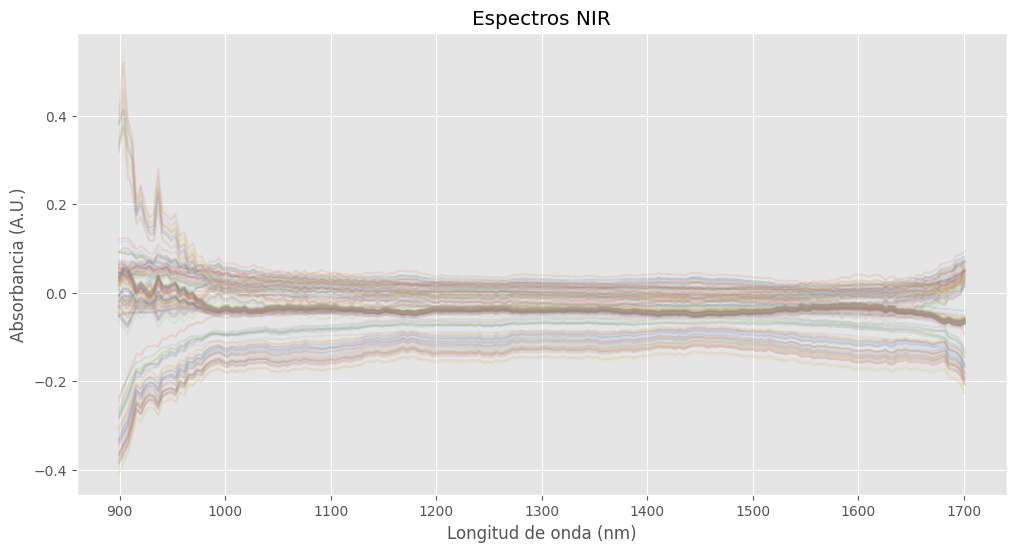

In [22]:
# ============================================================
# INSPECCIÓN VISUAL
# ============================================================

plt.figure(figsize=(12,6))

for i in range(len(spectra)):

    plt.plot(master_axis, spectra[i], alpha=0.12)

plt.xlabel("Longitud de onda (nm)")

plt.ylabel("Absorbancia (A.U.)")

plt.title("Espectros NIR")

plt.grid(True)

plt.show()

In [23]:
# ============================================================
# VALIDACIONES
# ============================================================

assert spectra.shape[0] == len(files)

assert spectra.shape[1] == len(master_axis)

assert not np.isnan(spectra).any()

assert np.all(np.diff(master_axis) > 0)

print("✓ Todos los espectros fueron cargados correctamente.")

✓ Todos los espectros fueron cargados correctamente.


In [24]:
print("="*50)

print("Número de espectros :", spectra.shape[0])

print("Variables espectrales :", spectra.shape[1])

print("Longitud mínima :", master_axis.min())

print("Longitud máxima :", master_axis.max())

print("="*50)

Número de espectros : 180
Variables espectrales : 204
Longitud mínima : 899.3452627794143
Longitud máxima : 1700.8300273203536


# PROMEDIO DE NIR


✓ Promedio calculado con éxito
-> Matriz original: (180, 204)
-> Matriz promediada: (30, 204) (63 frutos, 204 longitudes de onda)


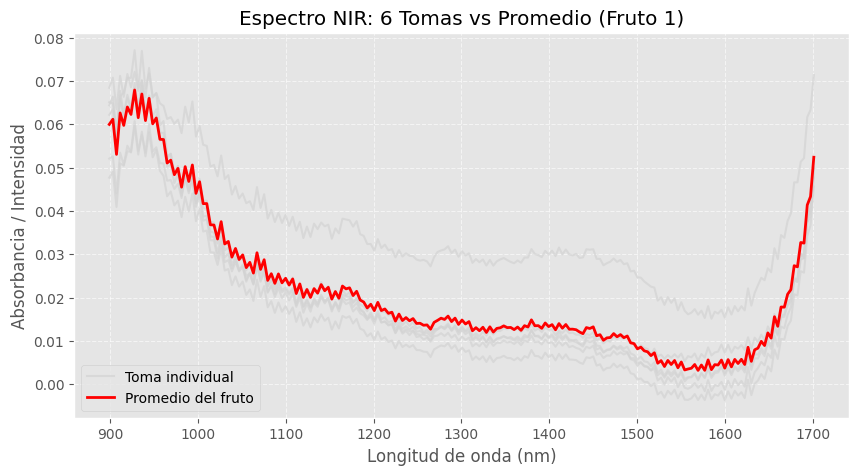

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CÁLCULO DEL ESPECTRO PROMEDIO POR FRUTO
# ============================================================

# 1. Definimos las variables base
n_espectros_totales = spectra.shape[0]  # 504
n_variables = spectra.shape[1]          # 204
mediciones_por_fruto = 6

# Calculamos la cantidad de frutos
n_frutos = n_espectros_totales // mediciones_por_fruto

# Validamos que no falten ni sobren datos
assert n_espectros_totales % mediciones_por_fruto == 0, "Error: El total de espectros no es múltiplo de 8."

# 2. Agrupación y Promedio
# Transformamos la matriz de (504, 204) a un cubo 3D de dimensiones (63, 8, 204)
# Esto agrupa las filas de 8 en 8.
spectra_agrupado = spectra.reshape((n_frutos, mediciones_por_fruto, n_variables))

# Calculamos el promedio a lo largo del eje 1 (donde están las 8 mediciones)
# Esto "aplasta" el cubo dejándolo en una matriz 2D de (63, 204)
spectra_promedio = np.mean(spectra_agrupado, axis=1)

# 3. Reporte de resultados
print("="*50)
print("✓ Promedio calculado con éxito")
print(f"-> Matriz original: {spectra.shape}")
print(f"-> Matriz promediada: {spectra_promedio.shape} (63 frutos, 204 longitudes de onda)")
print("="*50)

# ============================================================
# VISUALIZACIÓN DE VERIFICACIÓN (Opcional)
# ============================================================
# Graficamos el primer fruto para ver cómo el promedio (rojo)
# representa a las 8 mediciones individuales (gris)

plt.figure(figsize=(10, 5))

# Graficar las 8 mediciones del primer fruto (índice 0)
for i in range(6):
    plt.plot(master_axis, spectra_agrupado[0, i, :], color='lightgray', alpha=0.7,
             label='Toma individual' if i == 0 else "")

# Graficar el promedio del primer fruto
plt.plot(master_axis, spectra_promedio[0, :], color='red', linewidth=2, label='Promedio del fruto')

plt.title('Espectro NIR: 6 Tomas vs Promedio (Fruto 1)')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia / Intensidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Cálculo del °Brix Promedio por Muestra

In [29]:
import pandas as pd

# 1. Cargar el archivo Excel de datos destructivos
try:
    df_brix = pd.read_excel(PATH_BRIX)
    print("✓ Archivo de °Brix cargado con éxito.")
    print(f"-> Dimensiones iniciales del DataFrame: {df_brix.shape}")

    # Mostramos las primeras filas para verificar visualmente los nombres de las columnas
    print("\n--- Vista previa de los datos de Brix ---")
    print(df_brix.head(3))

    print("\n--- Lista completa de encabezados detectados ---")
    print(df_brix.columns.tolist())
except Exception as e:
    print(f"Error crítico al leer el archivo Excel: {e}")

✓ Archivo de °Brix cargado con éxito.
-> Dimensiones iniciales del DataFrame: (30, 4)

--- Vista previa de los datos de Brix ---
  Muestra_ID  Brix_A  Brix_B  Brix_C
0      MS-01    11.0       8     7.0
1      MS-02     5.0       5     6.0
2      MS-03    13.0      10    10.0

--- Lista completa de encabezados detectados ---
['Muestra_ID', 'Brix_A', 'Brix_B', 'Brix_C']


In [30]:
# ============================================================
# CÁLCULO DE MEDIA DE COOPERACIÓN Y ASOCIACIÓN DE VARIABLE "y"
# ============================================================

# REQUERIMIENTO: Definir aquí la lista exacta con los nombres de las 3 columnas de Brix
columnas_referencia = ['Brix_A', 'Brix_B', 'Brix_C']

# Verificación de la existencia de las columnas en el DataFrame
if all(col in df_brix.columns for col in columnas_referencia):

    # Calculamos el promedio a lo largo de las columnas (axis=1) para cada fila
    df_brix['Brix_Promedio'] = df_brix[columnas_referencia].mean(axis=1)

    # Extraemos el vector final de la variable objetivo (y)
    y_brix = df_brix['Brix_Promedio'].values

    # Validación crucial del Pipeline: Consistencia dimensional
    if len(y_brix) == spectra_promedio.shape[0]:
        print("="*60)
        print("✓ Pipeline Alineado: Espectros Promedio y °Brix Promedio")
        print(f"-> Matriz de características (X - spectra_promedio): {spectra_promedio.shape}")
        print(f"-> Vector objetivo consolidado (y - y_brix)       : {y_brix.shape}")
        print("="*60)

        # Análisis estadístico de control de los valores de Brix promedio
        print("Estadísticas descriptivas del °Brix Promedio:")
        print(f"  - Valor Mínimo : {y_brix.min():.2f} °Brix")
        print(f"  - Valor Máximo : {y_brix.max():.2f} °Brix")
        print(f"  - Media Global : {y_brix.mean():.2f} °Brix")
        print(f"  - Desviación Est.: {y_brix.std():.2f}")
    else:
        print(f" Alerta de Inconsistencia Dimensional:")
        print(f"   La matriz espectral tiene {spectra_promedio.shape[0]} muestras promediadas,")
        print(f"   pero el cálculo de Brix promedio generó {len(y_brix)} registros.")
else:
    print(" Error: Una o más columnas especificadas en 'columnas_referencia' no existen en el archivo.")
    print("Por favor, verifica la lista de encabezados de la celda anterior y ajusta los nombres.")

✓ Pipeline Alineado: Espectros Promedio y °Brix Promedio
-> Matriz de características (X - spectra_promedio): (30, 204)
-> Vector objetivo consolidado (y - y_brix)       : (30,)
Estadísticas descriptivas del °Brix Promedio:
  - Valor Mínimo : 5.00 °Brix
  - Valor Máximo : 21.00 °Brix
  - Media Global : 11.93 °Brix
  - Desviación Est.: 4.95


# Visualización de Espectros Promedio

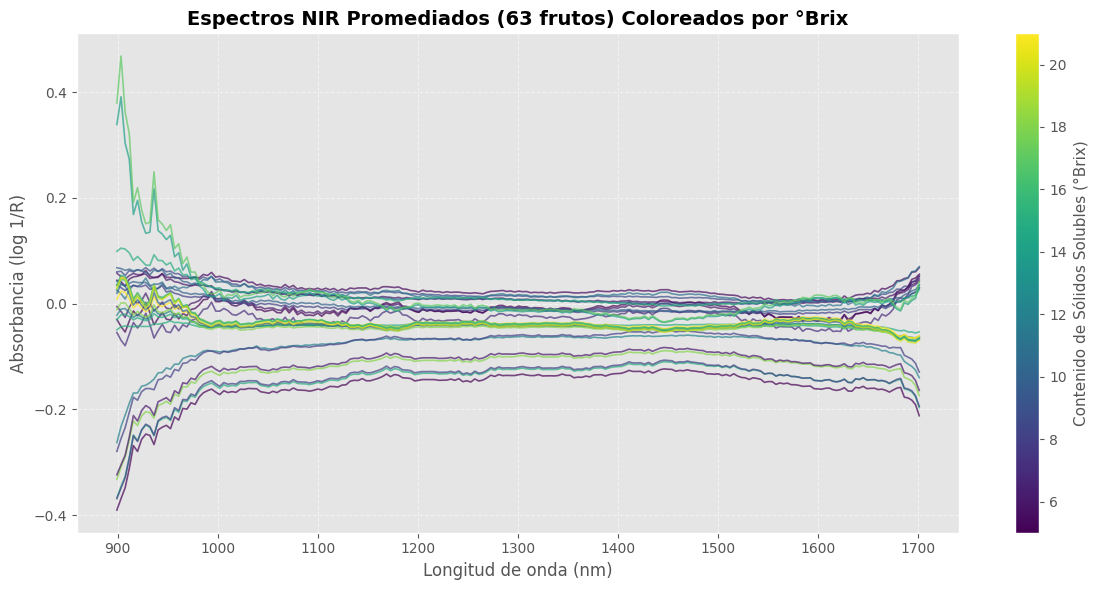

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ============================================================
# VISUALIZACIÓN DE ESPECTROS (COLOREADOS POR °BRIX)
# ============================================================

# Configuración del tamaño y estilo de la figura
plt.figure(figsize=(12, 6))

# Normalizamos los valores de Brix para asignarlos a un mapa de colores (colormap)
norm = plt.Normalize(y_brix.min(), y_brix.max())
cmap = cm.get_cmap('viridis')

# Graficamos cada uno de los 63 espectros iterando por las filas
for i in range(spectra_promedio.shape[0]):
    color_asignado = cmap(norm(y_brix[i]))
    plt.plot(master_axis, spectra_promedio[i, :], color=color_asignado, alpha=0.7, linewidth=1.2)

# Configuración de etiquetas y título
plt.title('Espectros NIR Promediados (63 frutos) Coloreados por °Brix', fontsize=14, fontweight='bold')
plt.xlabel('Longitud de onda (nm)', fontsize=12)
plt.ylabel('Absorbancia (log 1/R)', fontsize=12)

# Añadir una barra de color a la derecha para indicar la escala de Brix
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# --- CORRECCIÓN AQUÍ ---
# Agregamos ax=plt.gca() para indicarle a Matplotlib dónde ubicar la barra
cbar = plt.colorbar(sm, ax=plt.gca())
# -----------------------

cbar.set_label('Contenido de Sólidos Solubles (°Brix)', fontsize=11)

# Mejorar el estilo visual del grid
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# ANÁLISIS EXPLORATORIO

In [32]:
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import describe

In [33]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)

print(f"Número de muestras       : {spectra.shape[0]}")
print(f"Variables espectrales    : {spectra.shape[1]}")
print(f"Rango espectral          : {master_axis.min():.2f} - {master_axis.max():.2f} nm")
print(f"Brix mínimo              : {y_brix.min():.2f}")
print(f"Brix máximo              : {y_brix.max():.2f}")
print(f"Brix promedio            : {y_brix.mean():.2f}")
print(f"Desviación estándar      : {y_brix.std():.2f}")

print("="*60)

INFORMACIÓN DEL DATASET
Número de muestras       : 180
Variables espectrales    : 204
Rango espectral          : 899.35 - 1700.83 nm
Brix mínimo              : 5.00
Brix máximo              : 21.00
Brix promedio            : 11.93
Desviación estándar      : 4.95


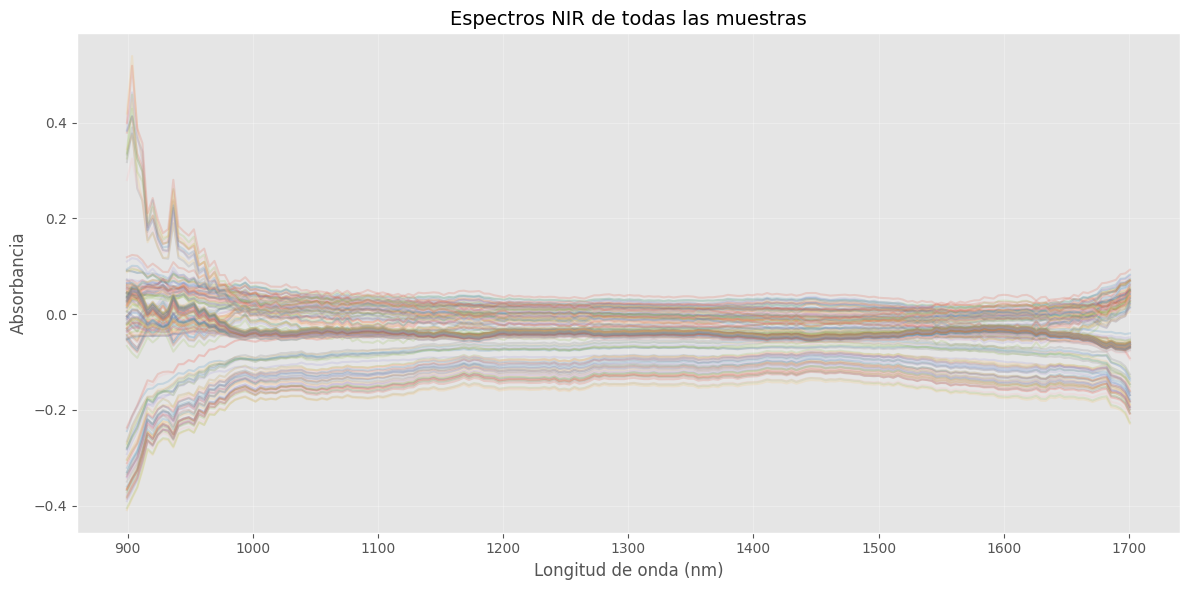

In [34]:
# ============================================================
# FIGURA 1
# TODOS LOS ESPECTROS
# ============================================================

plt.figure(figsize=(12,6))

for s in spectra:
    plt.plot(master_axis, s, alpha=0.18)

plt.xlabel("Longitud de onda (nm)", fontsize=12)
plt.ylabel("Absorbancia", fontsize=12)
plt.title("Espectros NIR de todas las muestras", fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

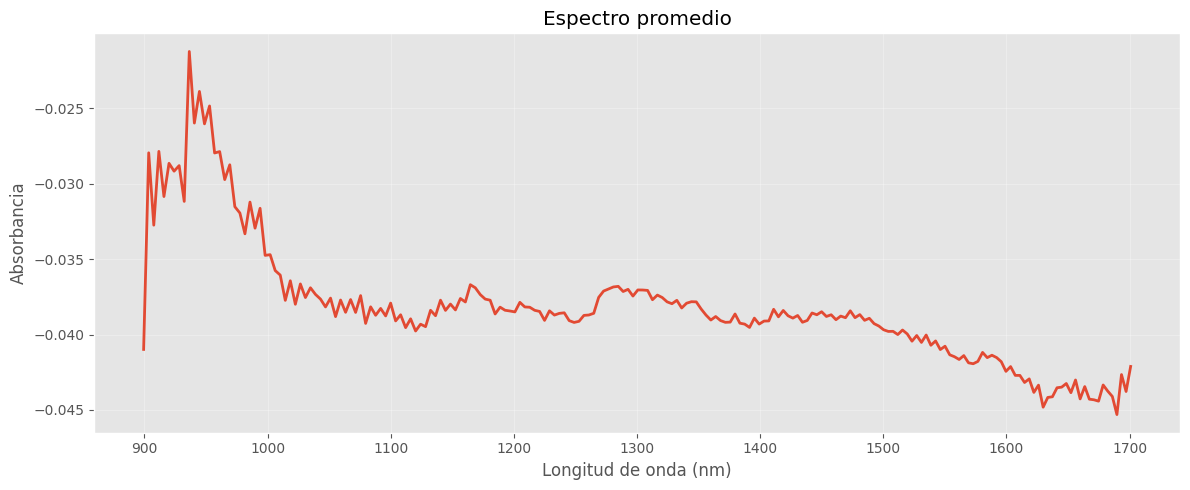

In [35]:
# ============================================================
# FIGURA 2
# ESPECTRO PROMEDIO
# ============================================================

mean_spectrum = spectra.mean(axis=0)

plt.figure(figsize=(12,5))

plt.plot(master_axis,
         mean_spectrum,
         linewidth=2)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Absorbancia")

plt.title("Espectro promedio")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

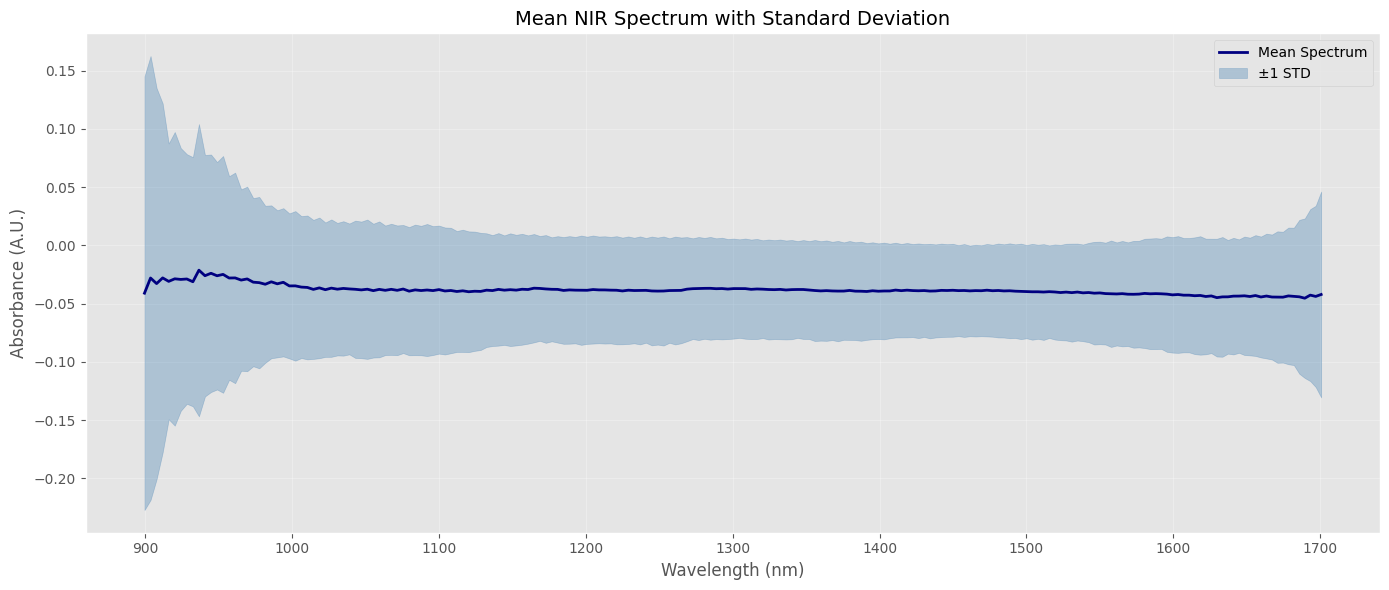

In [36]:
# ============================================================
# ESPECTRO PROMEDIO ±1 STD
# ============================================================

mean_spectrum = np.mean(spectra, axis=0)
std_spectrum = np.std(spectra, axis=0)

plt.figure(figsize=(14,6))

plt.plot(
    master_axis,
    mean_spectrum,
    color="navy",
    linewidth=2,
    label="Mean Spectrum"
)

plt.fill_between(
    master_axis,
    mean_spectrum-std_spectrum,
    mean_spectrum+std_spectrum,
    color="steelblue",
    alpha=0.35,
    label="±1 STD"
)

plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Absorbance (A.U.)", fontsize=12)

plt.title("Mean NIR Spectrum with Standard Deviation", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()

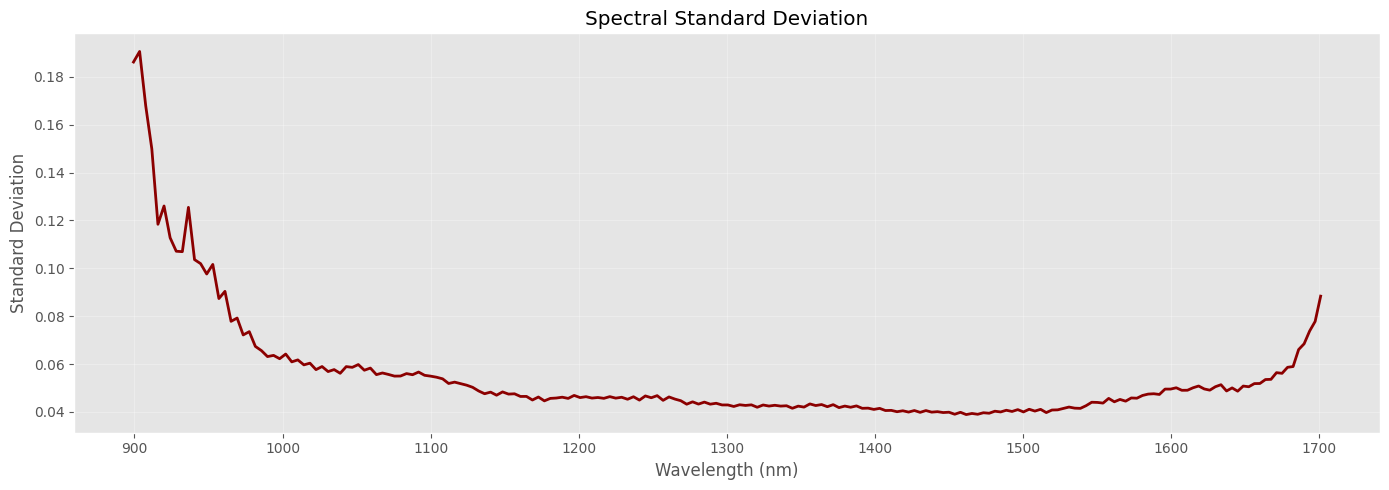

In [37]:
# ============================================================
# DESVIACIÓN ESTÁNDAR
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    master_axis,
    std_spectrum,
    linewidth=2,
    color="darkred"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Standard Deviation")

plt.title("Spectral Standard Deviation")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

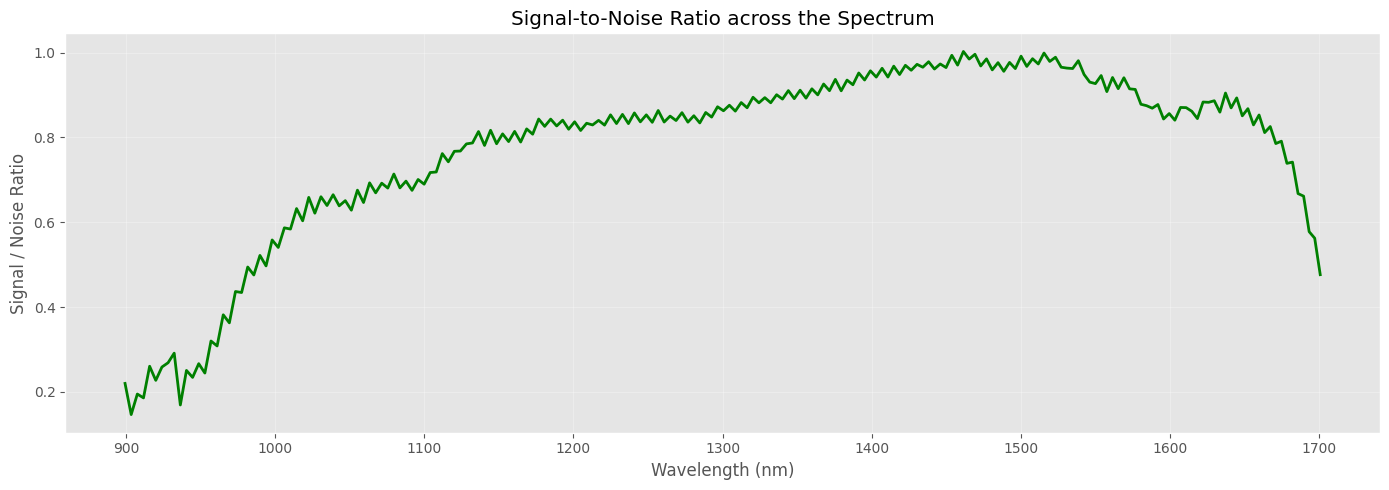

In [38]:
# ============================================================
# SIGNAL TO NOISE RATIO
# ============================================================

snr = np.abs(mean_spectrum) / (std_spectrum + 1e-8)

plt.figure(figsize=(14,5))

plt.plot(
    master_axis,
    snr,
    linewidth=2,
    color="green"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Signal / Noise Ratio")

plt.title("Signal-to-Noise Ratio across the Spectrum")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [39]:
print("="*60)

print("SNR mínimo :", snr.min())

print("SNR máximo :", snr.max())

print("SNR promedio :", snr.mean())

print("="*60)

SNR mínimo : 0.14669967462404357
SNR máximo : 1.0024997884946019
SNR promedio : 0.7793043773851608


In [40]:
threshold = np.percentile(snr,5)

bad_variables = np.where(snr<threshold)[0]

print(f"Variables con SNR bajo : {len(bad_variables)}")

Variables con SNR bajo : 11


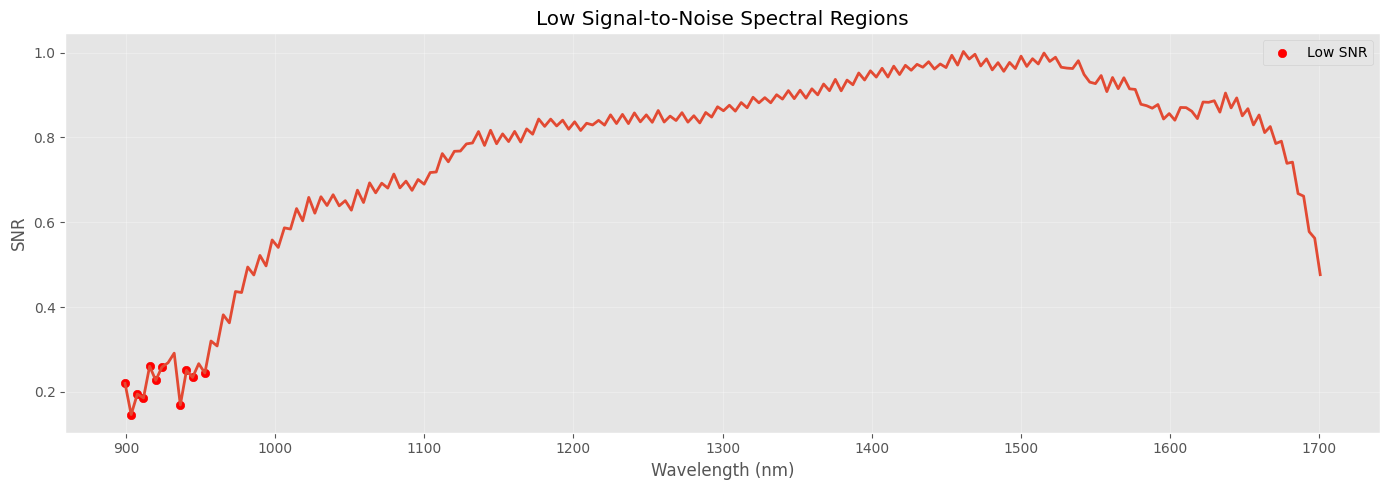

In [41]:
plt.figure(figsize=(14,5))

plt.plot(master_axis,
         snr,
         linewidth=2)

plt.scatter(master_axis[bad_variables],
            snr[bad_variables],
            color="red",
            label="Low SNR")

plt.xlabel("Wavelength (nm)")
plt.ylabel("SNR")

plt.title("Low Signal-to-Noise Spectral Regions")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [42]:
spectral_statistics = pd.DataFrame({

    "Wavelength_nm": master_axis,

    "Mean": mean_spectrum,

    "STD": std_spectrum,

    "SNR": snr

})

spectral_statistics.head()

,Wavelength_nm,Mean,STD,SNR
0,899.345263,-0.040988,0.186199,0.220132
1,903.470353,-0.027961,0.190601,0.146700
2,907.594255,-0.032755,0.167892,0.195094
3,911.716962,-0.027867,0.149859,0.185952
4,915.838464,-0.030858,0.118417,0.260587


In [43]:
spectral_statistics.to_csv(
    "Spectral_Statistics.csv",
    index=False
)

# PCA


PCA sobre RAW

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(
    with_mean=True,
    with_std=False
)

X_raw = spectra_promedio.copy()

scaler = StandardScaler(
    with_mean=True,
    with_std=False
)

X_centered = scaler.fit_transform(X_raw)

In [46]:
pca = PCA()

scores = pca.fit_transform(X_centered)

In [47]:
explained = pca.explained_variance_ratio_

cum = np.cumsum(explained)

for i in range(10):

    print(f"PC{i+1}: {explained[i]*100:.2f}%")

PC1: 92.84%
PC2: 6.44%
PC3: 0.56%
PC4: 0.09%
PC5: 0.04%
PC6: 0.02%
PC7: 0.00%
PC8: 0.00%
PC9: 0.00%
PC10: 0.00%


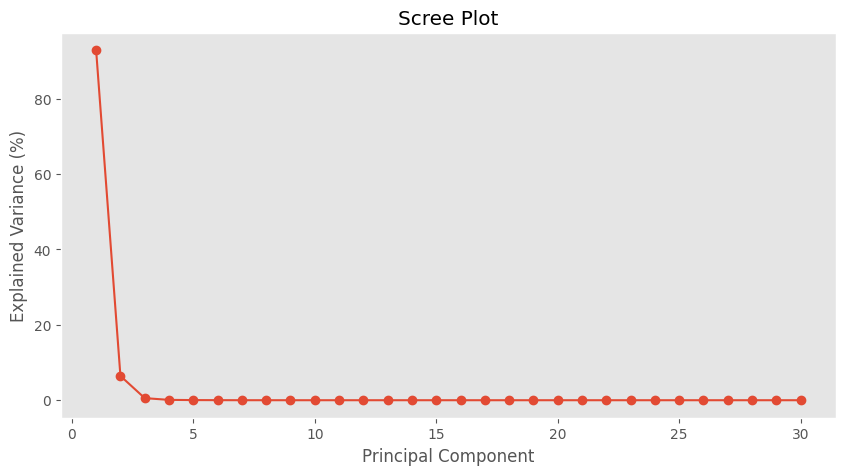

In [48]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1,len(explained)+1),
    explained*100,
    marker='o'
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance (%)")

plt.title("Scree Plot")

plt.grid()

plt.show()

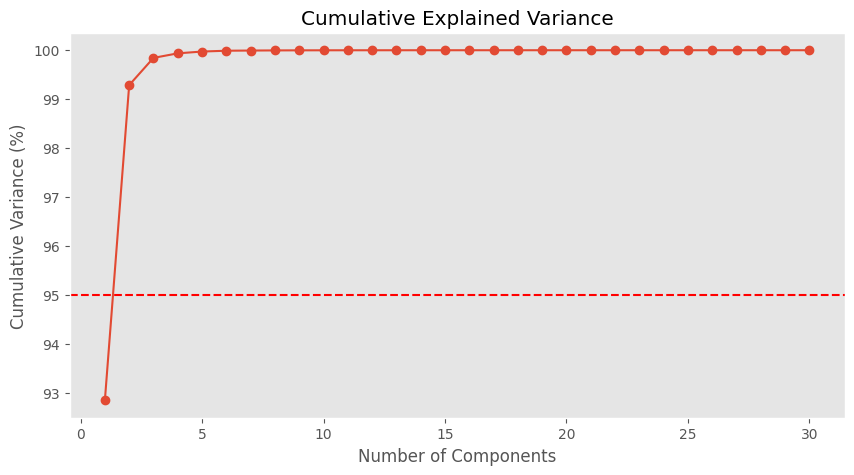

In [49]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1,len(cum)+1),
    cum*100,
    marker='o'
)

plt.axhline(
    95,
    color='red',
    linestyle='--'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance (%)")

plt.title("Cumulative Explained Variance")

plt.grid()

plt.show()

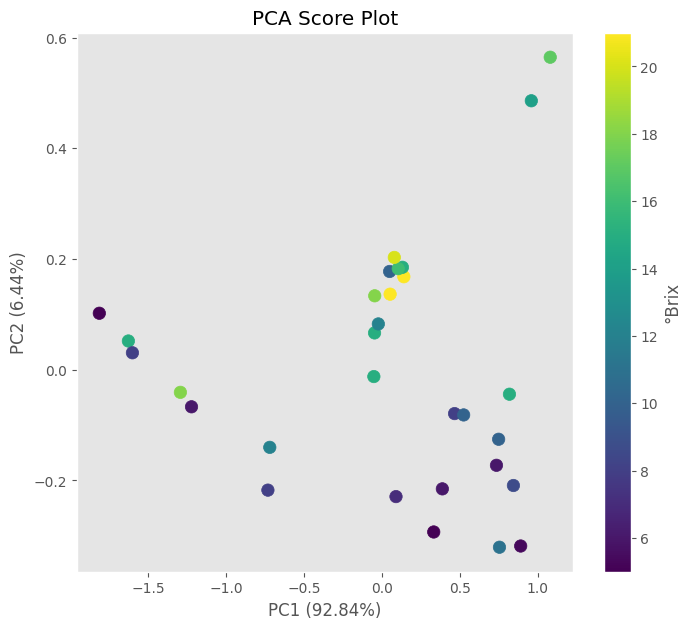

In [50]:
plt.figure(figsize=(8,7))

scatter = plt.scatter(
    scores[:,0],
    scores[:,1],
    c=y_brix,
    cmap="viridis",
    s=80
)

plt.xlabel(
    f"PC1 ({explained[0]*100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained[1]*100:.2f}%)"
)

plt.title("PCA Score Plot")

plt.grid()

plt.colorbar(
    scatter,
    label="°Brix"
)

plt.show()

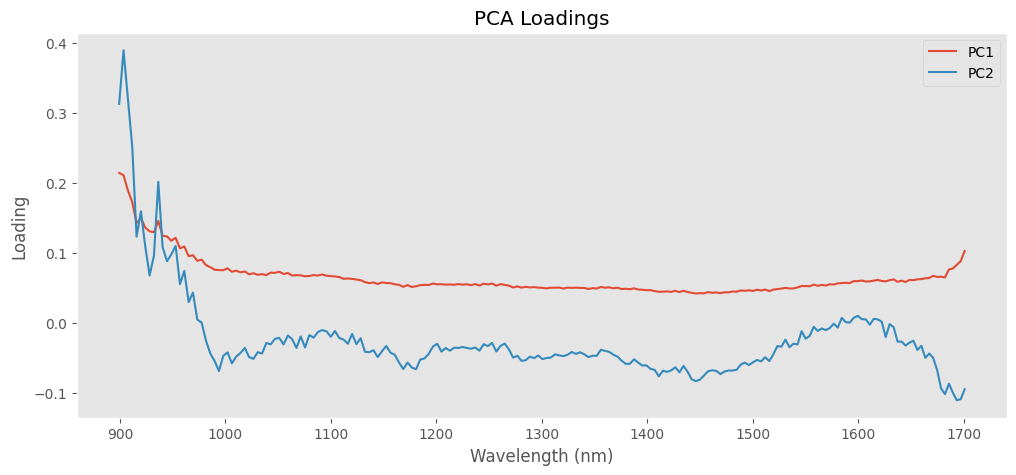

In [51]:
loadings = pca.components_

plt.figure(figsize=(12,5))

plt.plot(
    master_axis,
    loadings[0],
    label="PC1"
)

plt.plot(
    master_axis,
    loadings[1],
    label="PC2"
)

plt.xlabel("Wavelength (nm)")

plt.ylabel("Loading")

plt.title("PCA Loadings")

plt.legend()

plt.grid()

plt.show()

In [52]:
# Todos los espectros (8 por muestra)
X_all = spectra.copy()

# Espectro promedio por fruto
X_raw = spectra_promedio.copy()

# Variable objetivo
y = y_brix.copy()

In [53]:
# ============================================================
# VARIANZA EXPLICADA
# ============================================================

explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

variance_df = pd.DataFrame({
    "PC": np.arange(1, len(explained)+1),
    "Explained Variance (%)": explained*100,
    "Cumulative Variance (%)": cum*100
})

variance_df.head(10)

,PC,Explained Variance (%),Cumulative Variance (%)
0,1,92.844707,92.844707
1,2,6.442003,99.286711
2,3,0.556620,99.843331
3,4,0.092753,99.936084
4,5,0.036975,99.973058
5,6,0.016586,99.989645
6,7,0.003790,99.993434
7,8,0.002704,99.996138
8,9,0.001478,99.997617
9,10,0.001007,99.998624


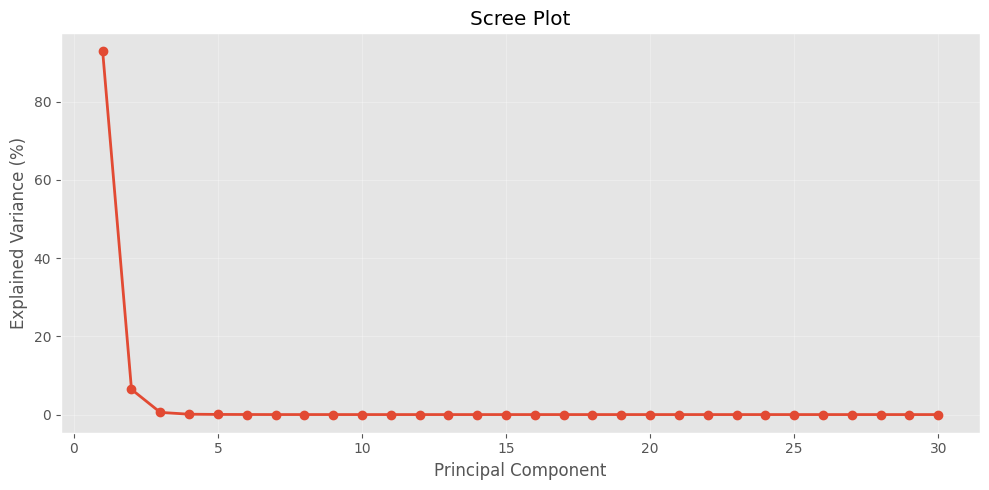

In [54]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1,len(explained)+1),
    explained*100,
    marker='o',
    linewidth=2
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

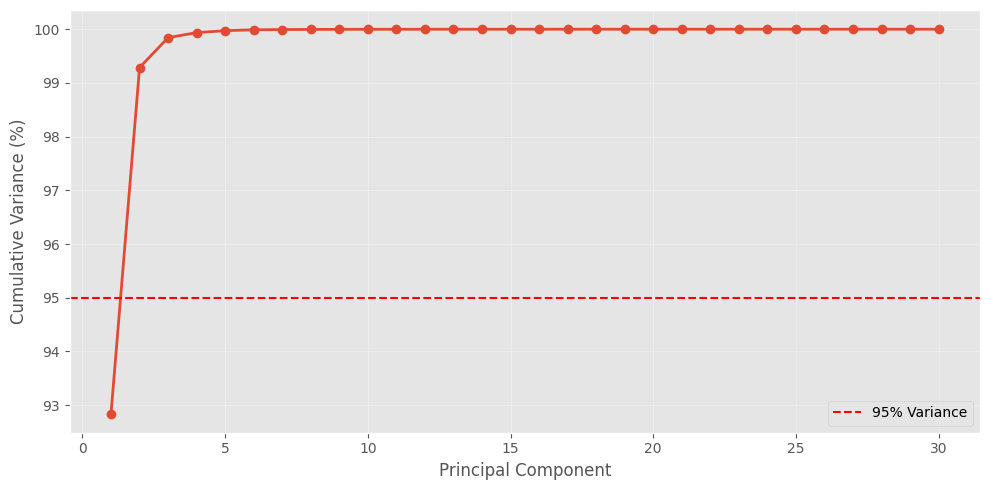

In [55]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1,len(cum)+1),
    cum*100,
    marker='o',
    linewidth=2
)

plt.axhline(
    95,
    color="red",
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance (%)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

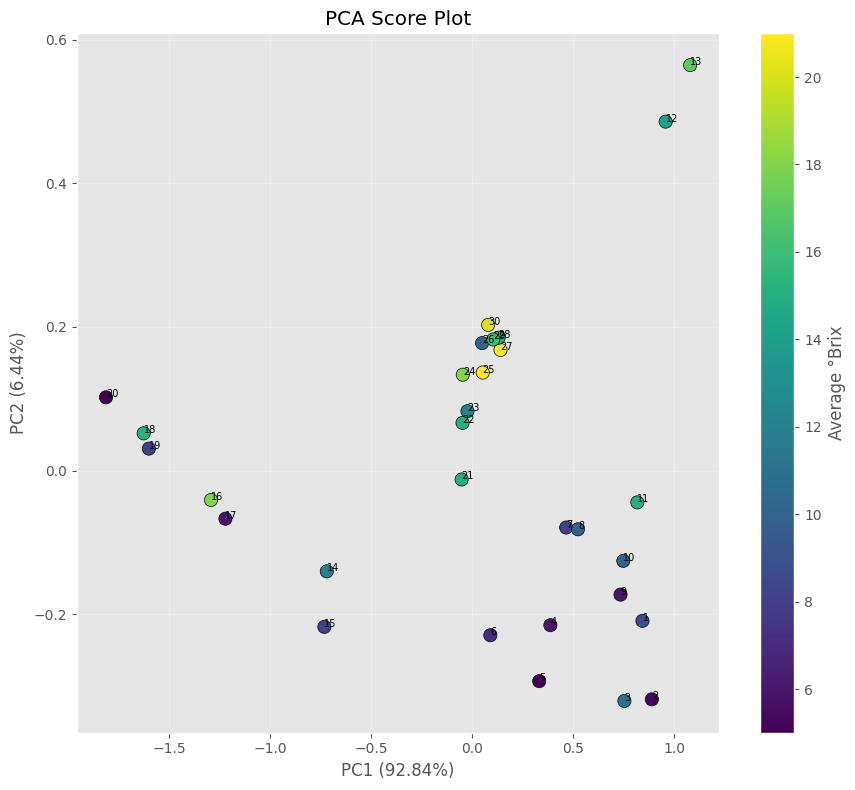

In [56]:
plt.figure(figsize=(9,8))

scatter = plt.scatter(
    scores[:,0],
    scores[:,1],
    c=y,
    cmap="viridis",
    edgecolor="black",
    s=90
)

for i in range(len(scores)):

    plt.text(
        scores[i,0],
        scores[i,1],
        str(i+1),
        fontsize=7
    )

plt.xlabel(f"PC1 ({explained[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.2f}%)")

plt.title("PCA Score Plot")

plt.grid(alpha=0.3)

plt.colorbar(
    scatter,
    label="Average °Brix"
)

plt.tight_layout()

plt.show()

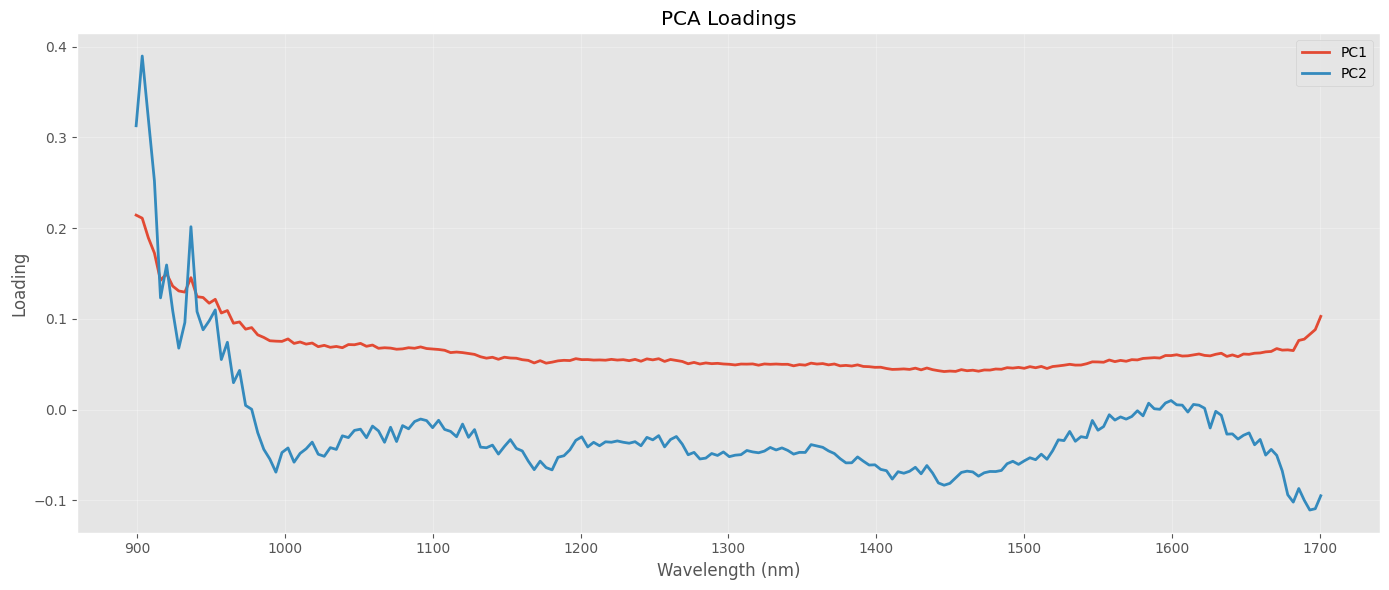

In [57]:
loadings = pca.components_

plt.figure(figsize=(14,6))

plt.plot(
    master_axis,
    loadings[0],
    label="PC1",
    linewidth=2
)

plt.plot(
    master_axis,
    loadings[1],
    label="PC2",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Loading")

plt.title("PCA Loadings")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [58]:
from scipy.stats import f

n = scores.shape[0]
a = 2

alpha = 0.95

F = f.ppf(alpha, a, n-a)

T2_limit = (a*(n-1)/(n-a))*F

T2 = np.sum(
    (scores[:,:2]**2)/pca.explained_variance_[:2],
    axis=1
)

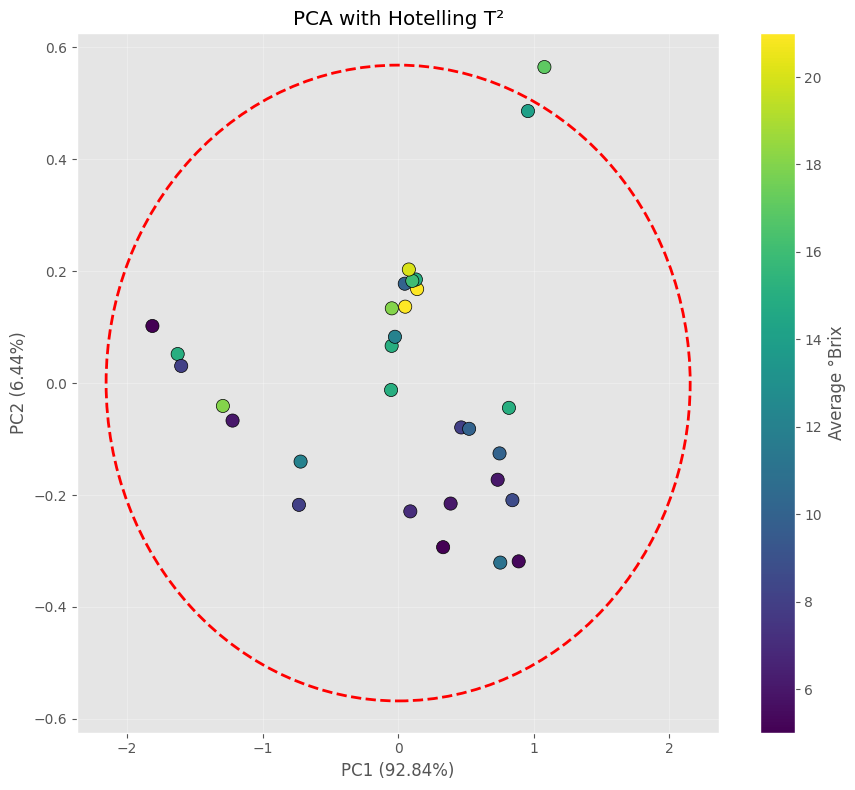

In [59]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(9,8))

scatter = ax.scatter(
    scores[:,0],
    scores[:,1],
    c=y,
    cmap="viridis",
    s=90,
    edgecolor="black"
)

eigvals = pca.explained_variance_[:2]

width = 2*np.sqrt(T2_limit*eigvals[0])

height = 2*np.sqrt(T2_limit*eigvals[1])

ellipse = Ellipse(
    (0,0),
    width,
    height,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
    linewidth=2
)

ax.add_patch(ellipse)

plt.colorbar(scatter,label="Average °Brix")

plt.xlabel(f"PC1 ({explained[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.2f}%)")

plt.title("PCA with Hotelling T²")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [60]:
outliers = np.where(T2 > T2_limit)[0]

print("Possible outliers:")

print(outliers+1)

Possible outliers:
[13]


In [61]:
from scipy.spatial.distance import mahalanobis

cov = np.cov(scores[:,:2].T)

inv_cov = np.linalg.inv(cov)

center = np.mean(scores[:,:2],axis=0)

md = []

for point in scores[:,:2]:

    md.append(
        mahalanobis(
            point,
            center,
            inv_cov
        )
    )

md = np.array(md)

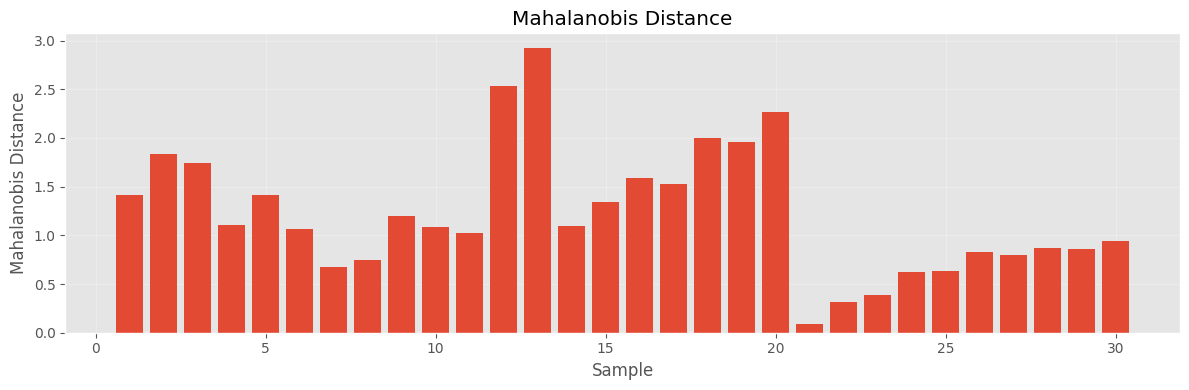

In [62]:
plt.figure(figsize=(12,4))

plt.bar(
    np.arange(1,len(md)+1),
    md
)

plt.xlabel("Sample")

plt.ylabel("Mahalanobis Distance")

plt.title("Mahalanobis Distance")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [63]:
threshold = np.mean(md)+3*np.std(md)

out_md = np.where(md>threshold)[0]

print("Mahalanobis Outliers")

print(out_md+1)

Mahalanobis Outliers
[]


In [64]:
pca_results = pd.DataFrame({

    "Sample": np.arange(1,len(scores)+1),

    "PC1": scores[:,0],

    "PC2": scores[:,1],

    "T2": T2,

    "Mahalanobis": md,

    "Brix": y

})

pca_results.to_csv(
    "PCA_Results.csv",
    index=False
)

# QUIMIOMETRÍA

In [65]:
# ============================================================
# BLOQUE 3
# PIPELINE QUIMIOMÉTRICO
# ============================================================

import numpy as np

import pandas as pd

from scipy.signal import savgol_filter

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize

from sklearn.model_selection import RepeatedKFold

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.base import clone

In [66]:
# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================

RANDOM_STATE = 42

# Validación cruzada
N_SPLITS = 5
N_REPEATS = 10

CV = RepeatedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

# Parámetros Savitzky-Golay
PREPROCESSING_CONFIG = {

    "window_length":11,

    "polyorder":2

}

print(CV)

RepeatedKFold(n_repeats=10, n_splits=5, random_state=42)


In [67]:
def preprocess_raw(X_train, X_test):

    return X_train.copy(), X_test.copy()

In [68]:
def preprocess_snv(X_train, X_test):

    X_train = (
        X_train -
        X_train.mean(axis=1, keepdims=True)
    ) / X_train.std(axis=1, keepdims=True)

    X_test = (
        X_test -
        X_test.mean(axis=1, keepdims=True)
    ) / X_test.std(axis=1, keepdims=True)

    return X_train, X_test

In [69]:
def preprocess_msc(X_train, X_test):

    reference = np.mean(X_train, axis=0)

    def msc(X):

        corrected = np.zeros_like(X)

        for i in range(X.shape[0]):

            slope, intercept = np.polyfit(
                reference,
                X[i],
                1
            )

            # Evitar divisiones por cero
            if np.abs(slope) < 1e-10:
                slope = 1e-10

            corrected[i] = (X[i] - intercept) / slope

        return corrected

    return msc(X_train), msc(X_test)

In [70]:
from sklearn.preprocessing import normalize

def preprocess_normalization(X_train, X_test):

    X_train = normalize(X_train, norm="l2")
    X_test = normalize(X_test, norm="l2")

    return X_train, X_test

In [71]:
def preprocess_savgol(X_train, X_test):

    window = PREPROCESSING_CONFIG["window_length"]

    poly = PREPROCESSING_CONFIG["polyorder"]

    return (

        savgol_filter(
            X_train,
            window,
            poly,
            axis=1,
            mode="nearest"
        ),

        savgol_filter(
            X_test,
            window,
            poly,
            axis=1,
            mode="nearest"
        )

    )

In [72]:
def preprocess_first_derivative(X_train, X_test):

    window = PREPROCESSING_CONFIG["window_length"]

    poly = PREPROCESSING_CONFIG["polyorder"]

    delta = np.mean(np.diff(master_axis))

    return (

        savgol_filter(
            X_train,
            window,
            poly,
            deriv=1,
            delta=delta,
            axis=1
        ),

        savgol_filter(
            X_test,
            window,
            poly,
            deriv=1,
            delta=delta,
            axis=1
        )

    )

In [73]:
def preprocess_second_derivative(X_train, X_test):

    window = PREPROCESSING_CONFIG["window_length"]

    poly = PREPROCESSING_CONFIG["polyorder"]

    delta = np.mean(np.diff(master_axis))

    return (

        savgol_filter(
            X_train,
            window,
            poly,
            deriv=2,
            delta=delta,
            axis=1
        ),

        savgol_filter(
            X_test,
            window,
            poly,
            deriv=2,
            delta=delta,
            axis=1
        )

    )

In [74]:
PREPROCESSORS = {

    "RAW": preprocess_raw,

    "SNV": preprocess_snv,

    "MSC": preprocess_msc,

    "Normalization": preprocess_normalization,

    "SavitzkyGolay": preprocess_savgol,

    "FirstDerivative": preprocess_first_derivative,

    "SecondDerivative": preprocess_second_derivative

}

In [75]:
# ============================================================
# VERIFICACIÓN DE PREPROCESAMIENTOS
# ============================================================

for fold, (train_idx, test_idx) in enumerate(CV.split(X_raw), start=1):

    X_train = X_raw[train_idx]
    X_test = X_raw[test_idx]

    print("="*60)
    print(f"FOLD {fold}")
    print("="*60)

    print(f"Train: {X_train.shape}")
    print(f"Test : {X_test.shape}")

    for name, func in PREPROCESSORS.items():

        Xt, Xv = func(X_train, X_test)

        print(
            f"{name:20}"
            f" Train {Xt.shape}"
            f" Test {Xv.shape}"
        )

    # Solo usamos el primer fold para verificar
    break

FOLD 1
Train: (24, 204)
Test : (6, 204)
RAW                  Train (24, 204) Test (6, 204)
SNV                  Train (24, 204) Test (6, 204)
MSC                  Train (24, 204) Test (6, 204)
Normalization        Train (24, 204) Test (6, 204)
SavitzkyGolay        Train (24, 204) Test (6, 204)
FirstDerivative      Train (24, 204) Test (6, 204)
SecondDerivative     Train (24, 204) Test (6, 204)


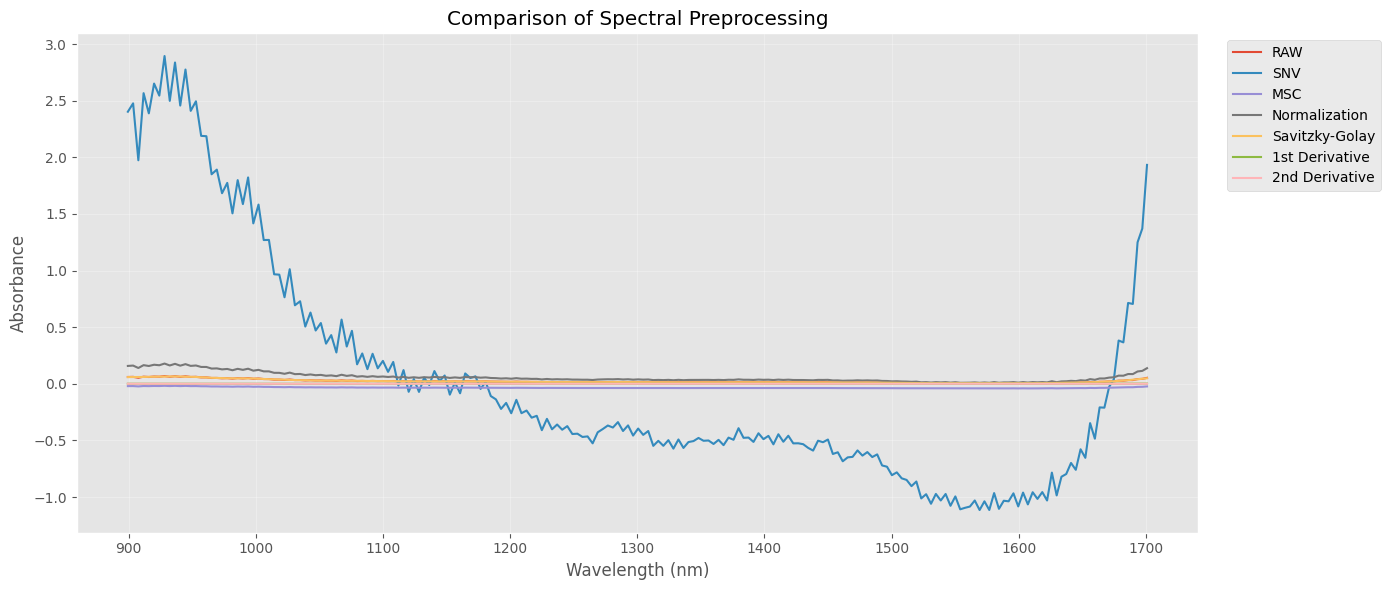

In [76]:
# ============================================================
# COMPARACIÓN VISUAL DE PREPROCESAMIENTOS
# ============================================================

sample = 0

Xt_raw, _ = preprocess_raw(X_train, X_test)
Xt_snv, _ = preprocess_snv(X_train, X_test)
Xt_msc, _ = preprocess_msc(X_train, X_test)
Xt_norm, _ = preprocess_normalization(X_train, X_test)
Xt_sg, _ = preprocess_savgol(X_train, X_test)
Xt_d1, _ = preprocess_first_derivative(X_train, X_test)
Xt_d2, _ = preprocess_second_derivative(X_train, X_test)

plt.figure(figsize=(14,6))

plt.plot(master_axis, Xt_raw[sample], label="RAW")
plt.plot(master_axis, Xt_snv[sample], label="SNV")
plt.plot(master_axis, Xt_msc[sample], label="MSC")
plt.plot(master_axis, Xt_norm[sample], label="Normalization")
plt.plot(master_axis, Xt_sg[sample], label="Savitzky-Golay")
plt.plot(master_axis, Xt_d1[sample], label="1st Derivative")
plt.plot(master_axis, Xt_d2[sample], label="2nd Derivative")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Comparison of Spectral Preprocessing")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Modelado

In [77]:
from sklearn.base import clone

from scipy.stats import pearsonr

In [78]:
def rmsep(y_true, y_pred):

    return np.sqrt(mean_squared_error(y_true,y_pred))

def bias(y_true,y_pred):

    return np.mean(y_pred-y_true)

def sep(y_true,y_pred):

    b = bias(y_true,y_pred)

    return np.sqrt(

        np.mean(

            ((y_pred-y_true)-b)**2

        )

    )

In [79]:
def rpd(y_true,y_pred):

    return np.std(y_true,ddof=1)/rmsep(y_true,y_pred)

In [80]:
def calculate_metrics(

    y_true,

    y_pred

):

    metrics = {}

    metrics["R2"] = r2_score(

        y_true,

        y_pred

    )

    metrics["RMSEP"] = rmsep(

        y_true,

        y_pred

    )

    metrics["MAE"] = mean_absolute_error(

        y_true,

        y_pred

    )

    metrics["Bias"] = bias(

        y_true,

        y_pred

    )

    metrics["SEP"] = sep(

        y_true,

        y_pred

    )

    metrics["RPD"] = rpd(

        y_true,

        y_pred

    )

    return metrics

In [81]:
def evaluate_model(
    model,
    preprocessing,
    X,
    y,
    cv
):
    """
    Evaluación universal para cualquier modelo de regresión.

    Parameters
    ----------
    model : modelo sklearn
    preprocessing : función de preprocesamiento
    X : matriz espectral
    y : variable objetivo
    cv : RepeatedKFold

    Returns
    -------
    dict
    """

    # ==========================================
    # Acumuladores
    # ==========================================

    y_true = []
    y_pred = []

    fold_results = []

    # ==========================================
    # Cross Validation
    # ==========================================

    for fold, (train_idx, test_idx) in enumerate(cv.split(X), start=1):

        # ------------------------------
        # División
        # ------------------------------

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        # ------------------------------
        # Preprocesamiento
        # ------------------------------

        preprocessing_function = PREPROCESSORS[preprocessing]

        X_train, X_test = preprocessing_function(
            X_train,
            X_test
        )

        # ------------------------------
        # Modelo
        # ------------------------------

        mdl = clone(model)

        mdl.fit(
            X_train,
            y_train
        )

        prediction = mdl.predict(X_test)

        # ------------------------------
        # Guardar resultados
        # ------------------------------

        y_true.extend(y_test)

        y_pred.extend(prediction)

        fold_results.append(

            pd.DataFrame({

                "Fold": fold,

                "Observed": y_test,

                "Predicted": prediction

            })

        )

    # ==========================================
    # Resultados finales
    # ==========================================

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    metrics = calculate_metrics(
        y_true,
        y_pred
    )

    residuals = y_true - y_pred

    results = pd.concat(
        fold_results,
        ignore_index=True
    )

    return {

        "metrics": metrics,

        "results": results,

        "y_true": y_true,

        "y_pred": y_pred,

        "residuals": residuals

    }

In [82]:
print(np.linalg.matrix_rank(X_train))

24


In [83]:
# ============================================================
# OPTIMIZACIÓN PLSR
# ============================================================

from sklearn.cross_decomposition import PLSRegression

plsr_results = []

# Nunca más componentes que muestras-1
max_components = min(20, X_raw.shape[1], X_raw.shape[0]-1)

for n_comp in range(2, max_components + 1):

    model = PLSRegression(
        n_components=n_comp
    )

    result = evaluate_model(

        model=model,

        preprocessing="SNV",   # luego probaremos todos

        X=X_raw,

        y=y,

        cv=CV

    )

    plsr_results.append({

        "Components": n_comp,

        **result["metrics"]

    })

plsr_results = pd.DataFrame(plsr_results)

plsr_results = plsr_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(plsr_results.head(10))

,Components,R2,RMSEP,MAE,Bias,SEP,RPD
0,2,0.357250,3.969435,3.203005,0.057573,3.969017,1.249408
1,3,0.339196,4.024798,3.232735,0.070184,4.024186,1.232221
2,5,0.327721,4.059593,3.353059,-0.012676,4.059574,1.221660
3,4,0.303741,4.131360,3.416934,0.108052,4.129947,1.200438
4,6,0.074905,4.762126,3.958485,-0.256831,4.755196,1.041434
5,7,-0.311455,5.670018,4.586800,-0.296934,5.662238,0.874678
6,8,-0.933025,6.883772,5.099883,-0.110407,6.882887,0.720454
7,9,-1.767891,8.237250,6.036450,0.082345,8.236838,0.602075
8,10,-3.176280,10.118183,7.292681,0.273759,10.114479,0.490151
9,11,-4.347875,11.449813,8.081193,0.675310,11.429880,0.433146


In [84]:
best_plsr = plsr_results.iloc[0]

print(best_plsr)

BEST_PLSR = PLSRegression(

    n_components=int(best_plsr["Components"])

)

Components    2.000000
R2            0.357250
RMSEP         3.969435
MAE           3.203005
Bias          0.057573
SEP           3.969017
RPD           1.249408
Name: 0, dtype: float64


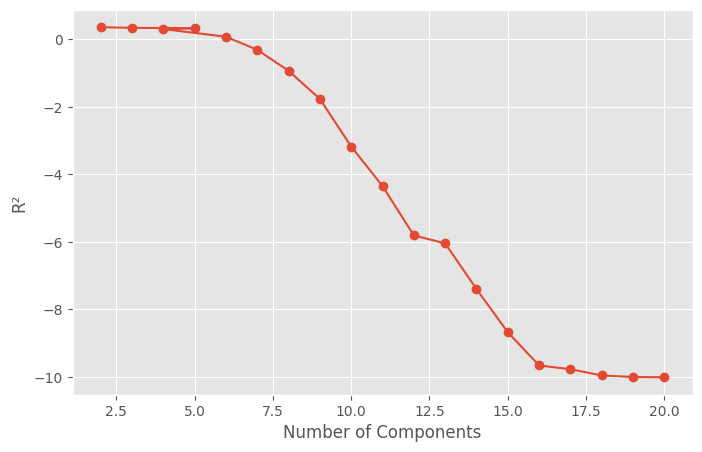

In [85]:
plt.figure(figsize=(8,5))

plt.plot(

    plsr_results["Components"],

    plsr_results["R2"],

    marker="o"

)

plt.xlabel("Number of Components")

plt.ylabel("R²")

plt.grid(True)

plt.show()

In [86]:
# ============================================================
# OPTIMIZACIÓN SVR
# ============================================================

from sklearn.svm import SVR

svr_results = []

C_values = [

    1,

    10,

    25,

    50,

    100

]

gamma_values = [

    "scale",

    0.001,

    0.005,

    0.01,

    0.05

]

for C in C_values:

    for gamma in gamma_values:

        model = SVR(

            kernel="rbf",

            C=C,

            gamma=gamma

        )

        result = evaluate_model(

            model=model,

            preprocessing="SNV",

            X=X_raw,

            y=y,

            cv=CV

        )

        svr_results.append({

            "C": C,

            "Gamma": gamma,

            **result["metrics"]

        })

svr_results = pd.DataFrame(svr_results)

svr_results = svr_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(svr_results.head(10))

,C,Gamma,R2,RMSEP,MAE,Bias,SEP,RPD
0,10,0.001,0.391578,3.861983,3.038016,-0.417912,3.839305,1.284170
1,25,0.001,0.365074,3.945202,3.107672,-0.295284,3.934137,1.257082
2,50,0.001,0.324599,4.069007,3.232913,-0.160246,4.065851,1.218833
3,100,0.001,0.298642,4.146461,3.313124,-0.105141,4.145127,1.196066
4,10,scale,0.286856,4.181155,3.443786,-0.186089,4.177012,1.186142
5,10,0.005,0.285675,4.184617,3.449351,-0.183715,4.180582,1.185160
6,25,scale,0.252256,4.281385,3.574091,-0.107195,4.280043,1.158373
7,25,0.005,0.249990,4.287865,3.582791,-0.108259,4.286499,1.156622
8,10,0.01,0.214876,4.387095,3.723551,-0.172172,4.383715,1.130462
9,50,scale,0.198280,4.433217,3.721697,-0.141361,4.430963,1.118700


In [87]:
best_svr = svr_results.iloc[0]

print(best_svr)

BEST_SVR = SVR(

    kernel="rbf",

    C=float(best_svr["C"]),

    gamma=best_svr["Gamma"]

)

C              10
Gamma       0.001
R2       0.391578
RMSEP    3.861983
MAE      3.038016
Bias    -0.417912
SEP      3.839305
RPD       1.28417
Name: 0, dtype: object


In [88]:
# ============================================================
# OPTIMIZACIÓN RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_results = []

trees = [

    100,

    200,

    300

]

depths = [

    5,

    10,

    15,

    None

]

leafs = [

    1,

    2,

    4

]

for n_tree in trees:

    for depth in depths:

        for leaf in leafs:

            model = RandomForestRegressor(

                n_estimators=n_tree,

                max_depth=depth,

                min_samples_leaf=leaf,

                random_state=RANDOM_STATE,

                n_jobs=-1

            )

            result = evaluate_model(

                model=model,

                preprocessing="RAW",

                X=X_raw,

                y=y,

                cv=CV

            )

            rf_results.append({

                "Trees": n_tree,

                "Depth": depth,

                "Leaf": leaf,

                **result["metrics"]

            })

rf_results = pd.DataFrame(rf_results)

rf_results = rf_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(rf_results.head(10))

,Trees,Depth,Leaf,R2,RMSEP,MAE,Bias,SEP,RPD
0,300,15.0,4,0.203065,4.419969,3.846284,0.158992,4.417108,1.122054
1,300,5.0,4,0.203065,4.419969,3.846284,0.158992,4.417108,1.122054
2,300,10.0,4,0.203065,4.419969,3.846284,0.158992,4.417108,1.122054
3,300,NaN,4,0.203065,4.419969,3.846284,0.158992,4.417108,1.122054
4,200,10.0,4,0.200039,4.428353,3.856200,0.159658,4.425474,1.119929
5,200,5.0,4,0.200039,4.428353,3.856200,0.159658,4.425474,1.119929
6,200,15.0,4,0.200039,4.428353,3.856200,0.159658,4.425474,1.119929
7,200,NaN,4,0.200039,4.428353,3.856200,0.159658,4.425474,1.119929
8,100,NaN,4,0.189698,4.456882,3.881227,0.138399,4.454733,1.112760
9,100,15.0,4,0.189698,4.456882,3.881227,0.138399,4.454733,1.112760


In [89]:
best_rf = rf_results.iloc[0]

print(best_rf)

BEST_RF = RandomForestRegressor(

    n_estimators=int(best_rf["Trees"]),

    max_depth=None if pd.isna(best_rf["Depth"]) else int(best_rf["Depth"]),

    min_samples_leaf=int(best_rf["Leaf"]),

    random_state=RANDOM_STATE,

    n_jobs=-1

)

Trees    300.000000
Depth     15.000000
Leaf       4.000000
R2         0.203065
RMSEP      4.419969
MAE        3.846284
Bias       0.158992
SEP        4.417108
RPD        1.122054
Name: 0, dtype: float64


In [90]:
from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    random_state=42

)
resultxgb = evaluate_model(
    model=xgb,
    preprocessing="SNV",
    X=X_raw,
    y=y,
    cv=CV
)

In [91]:
print(resultxgb["metrics"])

{'R2': 0.059405928159481536, 'RMSEP': np.float64(4.80185305384634), 'MAE': 3.9111479022767814, 'Bias': np.float64(-0.1330257495244343), 'SEP': np.float64(4.800010093811979), 'RPD': np.float64(1.0328182766864193)}


In [92]:
# ============================================================
# MODELOS OPTIMIZADOS
# ============================================================

from xgboost import XGBRegressor

MODELS = {

    "PLSR": BEST_PLSR,

    "SVR": BEST_SVR,

    "Random Forest": BEST_RF,

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective="reg:squarederror"
    )

}

In [93]:
# ============================================================
# COMPARACIÓN FINAL
# TODOS LOS MODELOS × TODOS LOS PREPROCESAMIENTOS
# ============================================================

experiment_results = []

all_results = {}

for prep_name in PREPROCESSORS.keys():

    print("=" * 70)
    print(f"Preprocessing: {prep_name}")
    print("=" * 70)

    for model_name, model in MODELS.items():

        result = evaluate_model(

            model=model,

            preprocessing=prep_name,

            X=X_raw,

            y=y,

            cv=CV

        )

        # Guardar resultados completos
        all_results[(model_name, prep_name)] = result

        metrics = result["metrics"]

        experiment_results.append({

            "Model": model_name,

            "Preprocessing": prep_name,

            "R2": metrics["R2"],

            "RMSEP": metrics["RMSEP"],

            "RPD": metrics["RPD"],

            "MAE": metrics["MAE"],

            "Bias": metrics["Bias"],

            "SEP": metrics["SEP"]

        })

        print(
            f"{model_name:15}"
            f" R²={metrics['R2']:.3f}"
            f" RMSEP={metrics['RMSEP']:.3f}"
            f" RPD={metrics['RPD']:.3f}"
        )

# ============================================================
# TABLA FINAL
# ============================================================

experiment_results = pd.DataFrame(experiment_results)

experiment_results = experiment_results.sort_values(

    "R2",

    ascending=False

).reset_index(drop=True)

display(experiment_results)

Preprocessing: RAW
PLSR            R²=0.245 RMSEP=4.303 RPD=1.153
SVR             R²=-0.218 RMSEP=5.464 RPD=0.908
Random Forest   R²=0.203 RMSEP=4.420 RPD=1.122
XGBoost         R²=-0.095 RMSEP=5.181 RPD=0.957
Preprocessing: SNV
PLSR            R²=0.357 RMSEP=3.969 RPD=1.249
SVR             R²=0.392 RMSEP=3.862 RPD=1.284
Random Forest   R²=0.345 RMSEP=4.006 RPD=1.238
XGBoost         R²=0.059 RMSEP=4.802 RPD=1.033
Preprocessing: MSC
PLSR            R²=-53149.942 RMSEP=1141.467 RPD=0.004
SVR             R²=-0.229 RMSEP=5.489 RPD=0.903
Random Forest   R²=0.037 RMSEP=4.858 RPD=1.021
XGBoost         R²=-0.158 RMSEP=5.329 RPD=0.931
Preprocessing: Normalization
PLSR            R²=0.296 RMSEP=4.155 RPD=1.194
SVR             R²=-0.203 RMSEP=5.431 RPD=0.913
Random Forest   R²=0.216 RMSEP=4.383 RPD=1.132
XGBoost         R²=-0.011 RMSEP=4.978 RPD=0.996
Preprocessing: SavitzkyGolay
PLSR            R²=0.238 RMSEP=4.323 RPD=1.147
SVR             R²=-0.218 RMSEP=5.465 RPD=0.908
Random Forest   R²=0.188

,Model,Preprocessing,R2,RMSEP,RPD,MAE,Bias,SEP
0,PLSR,FirstDerivative,0.419163,3.773416,1.314311,3.111423,0.048038,3.773110
1,PLSR,SecondDerivative,0.397050,3.844577,1.289984,3.194753,0.076069,3.843824
2,SVR,SNV,0.391578,3.861983,1.284170,3.038016,-0.417912,3.839305
3,Random Forest,FirstDerivative,0.376145,3.910655,1.268187,3.218362,-0.062209,3.910160
4,PLSR,SNV,0.357250,3.969435,1.249408,3.203005,0.057573,3.969017
5,Random Forest,SecondDerivative,0.352798,3.983159,1.245103,3.267294,0.073643,3.982478
6,Random Forest,SNV,0.345500,4.005555,1.238141,3.301907,-0.189432,4.001073
7,PLSR,Normalization,0.295830,4.154766,1.193675,3.456899,-0.023917,4.154697
8,PLSR,RAW,0.244765,4.302775,1.152615,3.501892,0.105333,4.301486
9,PLSR,SavitzkyGolay,0.237564,4.323241,1.147158,3.518887,0.106595,4.321926


In [ ]:
# ============================================================
# EXPORTAR RESULTADOS
# ============================================================

experiment_results.to_excel(
    "Resultados_Modelado_NIR.xlsx",
    index=False
)

print("Archivo guardado correctamente.")

In [ ]:
# ============================================================
# MEJOR MODELO
# ============================================================

best_row = experiment_results.iloc[0]

best_result = all_results[
    (
        best_row["Model"],
        best_row["Preprocessing"]
    )
]

print(best_row)

In [ ]:
# ============================================================
# OBSERVED VS PREDICTED
# ============================================================

y_true = best_result["y_true"]

y_pred = best_result["y_pred"]

plt.figure(figsize=(7,7))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.8,
    s=60
)

lims = [

    min(y_true.min(), y_pred.min()),

    max(y_true.max(), y_pred.max())

]

plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2
)

plt.xlabel("Observed °Brix")

plt.ylabel("Predicted °Brix")

plt.title(

    f"{best_row['Model']} ({best_row['Preprocessing']})"

)

plt.text(

    0.05,

    0.95,

    f"R² = {best_row['R2']:.3f}\nRMSEP = {best_row['RMSEP']:.3f}",

    transform=plt.gca().transAxes,

    verticalalignment="top",

    bbox=dict(facecolor="white", alpha=0.8)

)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# TOP 5 MODELOS
# ============================================================

top5 = experiment_results.head(5)

plt.figure(figsize=(9,5))

labels = [

    f"{m}\n({p})"

    for m, p in zip(

        top5["Model"],

        top5["Preprocessing"]

    )

]

plt.bar(

    labels,

    top5["R2"]

)

plt.ylabel("R²")

plt.title("Top 5 Models")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(

    labels,

    top5["RPD"]

)

plt.ylabel("RPD")

plt.title("Top 5 Models")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# RESUMEN DE MÉTRICAS
# ============================================================

summary = top5[
    [
        "Model",
        "Preprocessing",
        "R2",
        "RMSEP",
        "RPD"
    ]
].copy()

summary["Label"] = summary["Model"] + "\n(" + summary["Preprocessing"] + ")"

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(

    summary["Label"],

    summary["R2"],

    marker="o",

    label="R²"

)

ax1.plot(

    summary["Label"],

    summary["RPD"],

    marker="s",

    label="RPD"

)

ax1.set_ylabel("R² / RPD")

ax2 = ax1.twinx()

ax2.plot(

    summary["Label"],

    summary["RMSEP"],

    marker="^",

    linestyle="--",

    label="RMSEP"

)

ax2.set_ylabel("RMSEP")

ax1.grid(True)

fig.legend(loc="upper center", ncol=3)

plt.title("Performance Comparison of Top 5 Models")

plt.tight_layout()

plt.show()

In [94]:
import pickle

# Guardamos los modelos y el eje maestro de longitudes de onda
pipeline_data = {
    "master_axis": master_axis,
    "models": MODELS
}

with open("nir_bananaisla_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline_data, f)